# ADP Offline Training — Forward-Backward Algorithm

We train a **time-dependent linear Value Function Approximation (VFA)**:
$$\hat{V}_t(x_t;\, \eta_t) = \eta_t^\top \phi(x_t)$$

using Fitted Value Iteration with an initial forward pass:

1. **Forward pass** — simulate a heuristic policy over $N$ historical scenarios to collect realistic visited states $\{x_{n,t}\}$.
2. **Backward pass** — for $t = T{-}1 \ldots 0$, compute target values $V^*(x_{n,t})$ by solving a 1-step Pyomo MIQP lookahead using the already-fitted $\eta_{t+1}$.
3. **Regression** — fit $\eta_t$ by OLS: $\eta_t = \arg\min_\eta \sum_n (\eta^\top\phi(x_{n,t}) - V^*(x_{n,t}))^2$.
4. **Export** — save all $\eta_t$ ($t=0\ldots9$) to `output/adp_weights.json`.

### Basis functions $\phi(x_t) \in \mathbb{R}^7$

| Index | Feature | Motivation |
|-------|---------|------------|
| 0 | $(T_1 - T^{\mathrm{ok}})^2$ | Quadratic comfort penalty room 1 |
| 1 | $(T_2 - T^{\mathrm{ok}})^2$ | Quadratic comfort penalty room 2 |
| 2 | $H$ | Humidity level drives ventilation need |
| 3 | $c$ | Inertia counter; $c>0$ forces future ventilation cost |
| 4 | $\max(0,\, T^{\mathrm{low}} - T_1)$ | Soft cold-overrule penalty room 1 |
| 5 | $\max(0,\, T^{\mathrm{low}} - T_2)$ | Soft cold-overrule penalty room 2 |
| 6 | $1$ | Intercept |

The online policy (`ADP_policy_14.py`) reads `output/adp_weights.json` at import
time and uses $\eta_{t}$ for the current step.

In [1]:
import os, sys, json, time
import numpy as np
import pandas as pd
import pyomo.environ as pyo
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))
import v2_SystemCharacteristics as sc

raw = sc.get_fixed_data()

params = {
    'P_max'    : raw['heating_max_power'],
    'P_vent'   : raw['ventilation_power'],
    'T_low'    : raw['temp_min_comfort_threshold'],
    'T_ok'     : raw['temp_OK_threshold'],
    'T_high'   : raw['temp_max_comfort_threshold'],
    'H_high'   : raw['humidity_threshold'],
    'zeta_exch': raw['heat_exchange_coeff'],
    'zeta_loss': raw['thermal_loss_coeff'],
    'zeta_conv': raw['heating_efficiency_coeff'],
    'zeta_cool': raw['heat_vent_coeff'],
    'zeta_occ' : raw['heat_occupancy_coeff'],
    'eta_occ'  : raw['humidity_occupancy_coeff'],
    'eta_vent' : raw['humidity_vent_coeff'],
    'T_out'    : raw['outdoor_temperature'],
}

T_INIT = float(raw['T1'])   # 21.0 °C
H_INIT = float(raw['H'])    # 40.0 %
T      = 10
N_FEAT = 7

print("System parameters loaded.")
print(f"  T_low={params['T_low']} | T_ok={params['T_ok']} | T_high={params['T_high']} | H_high={params['H_high']}")
print(f"  P_max={params['P_max']} kW | P_vent={params['P_vent']} kW")

System parameters loaded.
  T_low=18.0 | T_ok=22.0 | T_high=26.0 | H_high=70.0
  P_max=3.0 kW | P_vent=2.0 kW


In [2]:
price_df = pd.read_csv('v2_PriceData.csv', header=0)
occ1_df  = pd.read_csv('OccupancyRoom1.csv', header=0)
occ2_df  = pd.read_csv('OccupancyRoom2.csv', header=0)

# v2_PriceData.csv: col0 = previous price, cols '1'..'10' = price at t=0..9
# OccupancyRoomX.csv: cols '0'..'9' = occupancy at t=0..9
price_cols = [str(i) for i in range(1, 11)]
occ_cols   = [str(i) for i in range(10)]

prices_all  = price_df[price_cols].values.astype(float)   # (N, 10)
prev_prices = price_df.iloc[:, 0].values.astype(float)    # (N,)
occ1_all    = occ1_df[occ_cols].values.astype(float)      # (N, 10)
occ2_all    = occ2_df[occ_cols].values.astype(float)      # (N, 10)

N = len(prices_all)
print(f"Loaded {N} days of historical data.")
print(f"  Price range: [{prices_all.min():.2f}, {prices_all.max():.2f}] euro/kWh")
print(f"  Occ1  range: [{occ1_all.min():.1f}, {occ1_all.max():.1f}] persons")
print(f"  Occ2  range: [{occ2_all.min():.1f}, {occ2_all.max():.1f}] persons")

Loaded 100 days of historical data.
  Price range: [0.00, 12.00] euro/kWh
  Occ1  range: [20.5, 47.5] persons
  Occ2  range: [14.1, 30.0] persons


In [ ]:
N_FEAT = 11

# Expected exogenous values for next-period (midpoints of scenario distributions)
# Used in solve_1step so training targets match online policy evaluation.
_E_OCC1_NEXT  = 30.0    # midpoint of Uniform(25, 35)
_E_OCC2_NEXT  = 20.0    # midpoint of Uniform(15, 25)
_E_PRICE_NEXT =  5.0    # midpoint of Uniform(2, 8)


def phi(state):
    """
    11-dimensional linear feature vector — all features scaled to O(1).

    [T1/30, T2/30, H/100, price/10, price_prev/10, occ1/40, occ2/30, c/2,
     pen1, pen2, 1]

    pen1 = max(0, 19.5 - T1) / 5  — early-warning hockey-stick for room 1
    pen2 = max(0, 19.5 - T2) / 5  — early-warning hockey-stick for room 2

    Normalization constants MUST match ADP_policy_14.py._phi().
    """
    T1 = float(state['T1'])
    T2 = float(state['T2'])
    return np.array([
        T1                                                 / 30.0,
        T2                                                 / 30.0,
        float(state.get('H', 0.0))                         / 100.0,
        float(state['price'])                              / 10.0,
        float(state.get('price_previous', state['price'])) / 10.0,
        float(state.get('occ1', 0.0))                      / 40.0,
        float(state.get('occ2', 0.0))                      / 30.0,
        float(state.get('c', 0))                           / 2.0,
        max(0.0, 19.5 - T1)                                / 5.0,
        max(0.0, 19.5 - T2)                                / 5.0,
        1.0,
    ], dtype=float)


# Sanity check
s_test = {'T1': 21.0, 'T2': 19.0, 'H': 45.0, 'c': 1,
          'price': 5.0, 'price_previous': 3.0, 'occ1': 30.0, 'occ2': 20.0}
print("phi(test) =", np.round(phi(s_test), 4))
print(f"  T1=21 → pen1=max(0,19.5-21)/5={max(0.0,19.5-21)/5:.2f}  (should be 0.0)")
print(f"  T2=19 → pen2=max(0,19.5-19)/5={max(0.0,19.5-19)/5:.2f}  (should be 0.1)")
print(f"N_FEAT={N_FEAT}  E_OCC1={_E_OCC1_NEXT}  E_OCC2={_E_OCC2_NEXT}  E_PRICE={_E_PRICE_NEXT}")

phi(test) = [0.7    0.6333 0.45   0.5    0.3    0.75   0.6667 0.5    0.     0.1
 1.    ]
  T1=21 → pen1=max(0,19.5-21)/5=0.00  (should be 0.0)
  T2=19 → pen2=max(0,19.5-19)/5=0.10  (should be 0.1)
N_FEAT=11  E_OCC1=30.0  E_OCC2=20.0  E_PRICE=5.0


In [4]:
def apply_dynamics(state, decisions):
    """One-step transition mirroring Task6_Environment.apply_dynamics."""
    p  = params
    t  = int(state['current_time'])
    p1 = float(decisions['HeatPowerRoom1'])
    p2 = float(decisions['HeatPowerRoom2'])
    v  = int(float(decisions['VentilationON']) > 0.5)
    H  = float(state.get('H', 0.0))
    c  = int(state.get('c', 0))

    if c > 0:                  v  = 1
    if H >= p['H_high']:       v  = 1
    if state.get('y_low_1'):   p1 = p['P_max']
    if state.get('y_low_2'):   p2 = p['P_max']
    if state.get('y_high_1'):  p1 = 0.0
    if state.get('y_high_2'):  p2 = 0.0

    step_cost = float(state['price']) * (p1 + p2 + p['P_vent'] * v)

    T_out = float(p['T_out'][min(t, 9)])
    T1 = float(state['T1']); T2 = float(state['T2'])
    occ1 = float(state.get('occ1', 0.0)); occ2 = float(state.get('occ2', 0.0))

    T1_n = (T1 + p['zeta_exch']*(T2-T1) + p['zeta_loss']*(T_out-T1)
            + p['zeta_conv']*p1 - p['zeta_cool']*v + p['zeta_occ']*occ1)
    T2_n = (T2 + p['zeta_exch']*(T1-T2) + p['zeta_loss']*(T_out-T2)
            + p['zeta_conv']*p2 - p['zeta_cool']*v + p['zeta_occ']*occ2)
    H_n  = max(0.0, H + p['eta_occ']*(occ1+occ2) - p['eta_vent']*v)
    c_n  = (2 if c == 0 else max(0, c-1)) if v == 1 else 0

    y_lo1 = (1 if T1_n < p['T_low'] else
             (0 if T1_n >= p['T_ok'] else int(state.get('y_low_1', 0))))
    y_lo2 = (1 if T2_n < p['T_low'] else
             (0 if T2_n >= p['T_ok'] else int(state.get('y_low_2', 0))))
    y_hi1 = 1 if T1_n > p['T_high'] else 0
    y_hi2 = 1 if T2_n > p['T_high'] else 0

    return {
        'T1': T1_n, 'T2': T2_n, 'H': H_n, 'c': c_n,
        'y_low_1': y_lo1, 'y_low_2': y_lo2,
        'y_high_1': y_hi1, 'y_high_2': y_hi2,
        'occ1': occ1, 'occ2': occ2,
        'price': float(state['price']),
        'price_previous': float(state['price']),
        'current_time': t + 1,
    }, step_cost


# ── Epsilon-greedy lazy heuristic ────────────────────────────────────────────
_EPS = 0.30    # 30 % of steps: fully random actions for boundary exploration

def heuristic_policy(state):
    """
    Epsilon-greedy lazy heuristic for the forward pass.

    With probability _EPS: fully random (p1, p2 ∈ [0, P_max], v ∈ {0,1}).
    This forces the forward pass to visit cold-room and ventilation-boundary
    states so the backward pass can fit the early-warning penalty weights.

    With probability (1 - _EPS): lazy heuristic — heats only when T < T_low+0.5
    to keep trajectories near the lower comfort bound.
    """
    p     = params
    T1    = float(state['T1'])
    T2    = float(state['T2'])
    H     = float(state.get('H', 0.0))
    c     = int(state.get('c', 0))
    P_max = p['P_max']
    T_low = p['T_low']

    if np.random.random() < _EPS:
        # Random exploration: sample uniformly and ignore overrule logic
        return {
            'HeatPowerRoom1': float(np.random.uniform(0, P_max)),
            'HeatPowerRoom2': float(np.random.uniform(0, P_max)),
            'VentilationON' : int(np.random.randint(0, 2)),
        }

    # Lazy heuristic (70 % of steps)
    v = 1 if (c > 0 or H >= p['H_high']) else int(H > 55.0)

    def heat(T_r, y_lo, y_hi):
        if y_hi:              return 0.0
        if y_lo:              return P_max
        if T_r < T_low + 0.5: return P_max
        return 0.0

    return {
        'HeatPowerRoom1': heat(T1, state.get('y_low_1', 0), state.get('y_high_1', 0)),
        'HeatPowerRoom2': heat(T2, state.get('y_low_2', 0), state.get('y_high_2', 0)),
        'VentilationON' : v,
    }

print("Dynamics and epsilon-greedy heuristic (ε=0.30) defined.")

Dynamics and epsilon-greedy heuristic (ε=0.30) defined.


## Step 1 — Forward Pass

Simulate the heuristic policy over all $N$ historical scenarios.
Each scenario uses realised historical prices and occupancies,
starting from the fixed initial state $(T^{\mathrm{init}}, H^{\mathrm{init}})$.

In [5]:
def run_forward_pass(policy_fn):
    """Simulate policy_fn over all N historical scenarios; return states[t][n].

    Initial temperatures are sampled from Uniform(17.5, 22.0) so the
    forward pass repeatedly visits the 18°C overrule boundary, enabling
    the backward pass to fit pen1/pen2 feature weights accurately.
    """
    states_out = [[None] * N for _ in range(T)]
    for n in range(N):
        T1_init = float(np.random.uniform(17.5, 22.0))
        T2_init = float(np.random.uniform(17.5, 22.0))
        state = {
            'T1': T1_init, 'T2': T2_init, 'H': H_INIT,
            'c': 0, 'y_low_1': 0, 'y_low_2': 0, 'y_high_1': 0, 'y_high_2': 0,
            'occ1': float(occ1_all[n, 0]), 'occ2': float(occ2_all[n, 0]),
            'price': float(prices_all[n, 0]),
            'price_previous': float(prev_prices[n]),
            'current_time': 0,
        }
        for t in range(T):
            state['price']          = float(prices_all[n, t])
            state['price_previous'] = float(prices_all[n, t-1]) if t > 0 else float(prev_prices[n])
            state['occ1']           = float(occ1_all[n, t])
            state['occ2']           = float(occ2_all[n, t])
            state['current_time']   = t
            states_out[t][n] = dict(state)
            state, _ = apply_dynamics(state, policy_fn(state))

    T1_mid = [states_out[5][n]['T1'] for n in range(N)]
    print(f"    T1@t=5: mean={np.mean(T1_mid):.2f}  min={np.min(T1_mid):.2f}  max={np.max(T1_mid):.2f}")
    return states_out

print("run_forward_pass defined (start temps ~ Uniform(17.5, 22.0)).")

run_forward_pass defined (start temps ~ Uniform(17.5, 22.0)).


## Step 2 — Backward Pass + OLS Regression

For each $t = 9, 8, \ldots, 0$ (backwards):

1. Solve the 1-step MIQP for every sampled state $x_{n,t}$:
   $$V^*(x_{n,t}) = \min_{p_1,p_2,v}\;\Bigl\{\lambda_{n,t}(p_1+p_2+P_{\text{vent}}\,v) + \eta_{t+1}^\top\phi\bigl(x_{n,t+1}(p_1,p_2,v)\bigr)\Bigr\}$$
   The VFA of the next state is expressed directly as Pyomo expressions
   through the post-decision dynamics (MIQP because of the quadratic terms).

2. Fit $\eta_t$ by OLS on $(\Phi_t, V^*_t)$.

Terminal condition: $\eta_{10} = \mathbf{0}$.

In [ ]:
BIG_M = 1_000


def solve_1step(state, eta_next, return_action=False):
    """
    1-step linear MILP — Bellman evaluation under expected exogenous variables.

    Because the VFA is strictly linear and the dynamics are linear in the
    exogenous variables, E[V(x_{t+1})] = V(E[x_{t+1}]).  We therefore plug
    in the expected next-period values (_E_OCC1_NEXT, _E_OCC2_NEXT,
    _E_PRICE_NEXT) for the phi features, keeping the model a standard MILP
    with no quadratic terms and no NonConvex flag.

    Early-warning penalty features (pen1x, pen2x = max(0, 19.5-T_rx)/5):
    Linearized via auxiliary LP variables.  With positive eta[8]/eta[9],
    minimisation drives each pen_rx to max(0, (19.5-T_rx)/5).

    Regression target (return_action=False):
    Adds +50 artificial pain when an overrule was already active in the
    current state, so Ridge learns that states near/below T_low carry
    high future cost — giving the pen features strongly positive weights.
    This artificial pain is NOT added to the Pyomo objective.

    return_action=True  →  return optimal {p1, p2, v} dict (for forward pass)
    return_action=False →  return Bellman target scalar (for regression)
    """
    p      = params
    P_max  = p['P_max']
    t      = int(state.get('current_time', 0))
    T_out  = float(p['T_out'][min(t, 9)])
    T1     = float(state['T1'])
    T2     = float(state['T2'])
    H      = float(state.get('H', 0.0))
    c      = int(state.get('c', 0))
    occ1   = float(state.get('occ1', 0.0))
    occ2   = float(state.get('occ2', 0.0))
    price  = float(state['price'])
    eta    = eta_next

    m = pyo.ConcreteModel()
    m.p1  = pyo.Var(bounds=(0, P_max))
    m.p2  = pyo.Var(bounds=(0, P_max))
    m.v   = pyo.Var(domain=pyo.Binary)
    m.T1x = pyo.Var()
    m.T2x = pyo.Var()
    m.Hx  = pyo.Var()

    # Dynamics: realized occ1/occ2 drive the physical next state
    m.dT1 = pyo.Constraint(expr=
        m.T1x == T1 + p['zeta_exch']*(T2-T1) + p['zeta_loss']*(T_out-T1)
               + p['zeta_conv']*m.p1 - p['zeta_cool']*m.v + p['zeta_occ']*occ1)
    m.dT2 = pyo.Constraint(expr=
        m.T2x == T2 + p['zeta_exch']*(T1-T2) + p['zeta_loss']*(T_out-T2)
               + p['zeta_conv']*m.p2 - p['zeta_cool']*m.v + p['zeta_occ']*occ2)
    m.dH  = pyo.Constraint(expr=
        m.Hx  == H + p['eta_occ']*(occ1+occ2) - p['eta_vent']*m.v)

    # c_next linearisation
    if   c == 0: c_next = 2.0 * m.v
    elif c == 1: c_next = 0.0
    else:        c_next = 1.0

    # LP linearisation of max(0, 19.5 - T_rx) / 5.0
    # With eta[8], eta[9] > 0: minimisation drives pen_rx to its lower bound
    # = max(0, (19.5 - T_rx) / 5.0).  Upper bound of 5.0 prevents unboundedness
    # in iterations where a weight is transiently negative.
    m.pen1x   = pyo.Var(bounds=(0, 5.0))
    m.pen2x   = pyo.Var(bounds=(0, 5.0))
    m.c_pen1x = pyo.Constraint(expr=m.pen1x >= (19.5 - m.T1x) / 5.0)
    m.c_pen2x = pyo.Constraint(expr=m.pen2x >= (19.5 - m.T2x) / 5.0)

    # Soft overrule penalties (guidance only — excluded from returned target)
    penalty_terms = []
    if c > 0 or H >= p['H_high']:
        penalty_terms.append(BIG_M * (1 - m.v))
    if state.get('y_low_1'):
        penalty_terms.append(BIG_M * (P_max - m.p1))
    if state.get('y_low_2'):
        penalty_terms.append(BIG_M * (P_max - m.p2))
    if state.get('y_high_1'):
        penalty_terms.append(BIG_M * m.p1)
    if state.get('y_high_2'):
        penalty_terms.append(BIG_M * m.p2)
    overrule_penalty = sum(penalty_terms) if penalty_terms else 0.0

    # Linear VFA of expected next state (11 features)
    # phi = [T1x/30, T2x/30, Hx/100, E[price]/10, price_t/10,
    #        E[occ1]/40, E[occ2]/30, c_next/2, pen1x, pen2x, 1]
    vfa_next = (eta[0] *(m.T1x         / 30.0) +
                eta[1] *(m.T2x         / 30.0) +
                eta[2] *(m.Hx          / 100.0) +
                eta[3] *(_E_PRICE_NEXT / 10.0) +
                eta[4] *(price         / 10.0) +
                eta[5] *(_E_OCC1_NEXT  / 40.0) +
                eta[6] *(_E_OCC2_NEXT  / 30.0) +
                eta[7] *(c_next        / 2.0) +
                eta[8] * m.pen1x +
                eta[9] * m.pen2x +
                eta[10])

    m.obj = pyo.Objective(
        expr=price*(m.p1 + m.p2 + p['P_vent']*m.v) + vfa_next + overrule_penalty,
        sense=pyo.minimize)

    solver = pyo.SolverFactory('gurobi')
    solver.options['OutputFlag'] = 0
    result = solver.solve(m)

    if result.solver.termination_condition != pyo.TerminationCondition.optimal:
        return None

    p1_val  = float(pyo.value(m.p1))
    p2_val  = float(pyo.value(m.p2))
    v_val   = int(round(pyo.value(m.v)))
    T1x_val = float(pyo.value(m.T1x))
    T2x_val = float(pyo.value(m.T2x))
    Hx_val  = float(pyo.value(m.Hx))

    if return_action:
        return {'HeatPowerRoom1': p1_val, 'HeatPowerRoom2': p2_val, 'VentilationON': v_val}

    # Bellman target = immediate cost + artificial pain + VFA(expected next state)
    # +50 artificial pain when overrule was active: teaches pen features that
    # states near/below T_low carry high future cost.  NOT in Pyomo objective.
    if   c == 0: c_next_val = 2.0 * v_val
    elif c == 1: c_next_val = 0.0
    else:        c_next_val = 1.0

    pen1x_val = max(0.0, (19.5 - T1x_val) / 5.0)
    pen2x_val = max(0.0, (19.5 - T2x_val) / 5.0)

    pain      = 50.0 if (state.get('y_low_1') or state.get('y_low_2')) else 0.0
    immediate = price * (p1_val + p2_val + p['P_vent'] * v_val) + pain
    vfa_val   = (eta[0] *(T1x_val       / 30.0) +
                 eta[1] *(T2x_val       / 30.0) +
                 eta[2] *(Hx_val        / 100.0) +
                 eta[3] *(_E_PRICE_NEXT / 10.0) +
                 eta[4] *(price         / 10.0) +
                 eta[5] *(_E_OCC1_NEXT  / 40.0) +
                 eta[6] *(_E_OCC2_NEXT  / 30.0) +
                 eta[7] *(c_next_val    / 2.0) +
                 eta[8] * pen1x_val +
                 eta[9] * pen2x_val +
                 eta[10])
    return immediate + vfa_val


print("solve_1step defined — 11-feature MILP, pen1x/pen2x LP linearisation,")
print("  artificial pain (+50) in regression target when overrule active.")

solve_1step defined — 11-feature MILP, pen1x/pen2x LP linearisation,
  artificial pain (+50) in regression target when overrule active.


In [ ]:
from sklearn.linear_model import Ridge

# ── API hyper-parameters ──────────────────────────────────────────────────────
N_OUTER = 10     # outer API iterations (forward + backward + mix)
BETA    = 0.25   # policy mixing rate: eta_new = BETA*fitted + (1-BETA)*eta_old
_EPS    = 0.10   # epsilon-greedy exploration in the ADP forward-pass policy

# Terminal condition: V_T = 0
eta_all = np.zeros((T + 1, N_FEAT))


# ── Backward pass ─────────────────────────────────────────────────────────────
def run_backward_pass(states, eta_old):
    """
    Compute Bellman targets for all (n, t) pairs and fit eta_t by Ridge.
    Policy mixing: eta[t] = BETA * fitted + (1 - BETA) * eta_old[t].
    """
    eta = np.zeros((T + 1, N_FEAT))
    print(f"  {'t':>2}  {'solved':>8}  {'skip':>4}  {'RMSE':>8}  weights (11 values)")
    print("  " + "-" * 100)
    t0 = time.perf_counter()
    for t in range(T - 1, -1, -1):
        eta_next = eta[t + 1]
        targets, rows, n_skip = [], [], 0
        for n in range(N):
            v_star = solve_1step(states[t][n], eta_next)
            if v_star is None or not np.isfinite(v_star):
                n_skip += 1
                continue
            targets.append(v_star)
            rows.append(phi(states[t][n]))
        n_valid = len(targets)
        if n_valid < N_FEAT:
            eta[t] = eta_old[t]
            print(f"  t={t}  solved={n_valid}/{N}  WARN: too few — keeping old weights")
            continue
        Phi   = np.array(rows)
        y     = np.array(targets)
        ridge = Ridge(alpha=1.0, fit_intercept=False)
        ridge.fit(Phi, y)
        eta_t_raw = ridge.coef_
        eta[t]    = BETA * eta_t_raw + (1.0 - BETA) * eta_old[t]   # policy mixing
        rmse      = float(np.sqrt(np.mean((Phi @ eta[t] - y)**2)))
        print(f"  t={t:>1}  solved={n_valid:>4}/{N:<4}  skip={n_skip:>3}"
              f"  rmse={rmse:>8.3f}  {np.round(eta[t], 3)}")
    print(f"  Backward pass done in {(time.perf_counter()-t0)/60:.1f} min.")
    return eta


# ── ADP greedy policy with epsilon-greedy exploration ─────────────────────────
def adp_policy(state):
    """
    Reads the current global eta_all (updated after each outer iteration).
    Falls back to heuristic_policy if the MILP returns None.
    """
    t     = int(state.get('current_time', 0))
    P_max = params['P_max']
    if np.random.random() < _EPS:
        return {'HeatPowerRoom1': float(np.random.uniform(0, P_max)),
                'HeatPowerRoom2': float(np.random.uniform(0, P_max)),
                'VentilationON' : int(np.random.randint(0, 2))}
    eta_next = eta_all[min(t + 1, T)]
    action   = solve_1step(state, eta_next, return_action=True)
    return action if action is not None else heuristic_policy(state)


# ── Outer API loop ────────────────────────────────────────────────────────────
t_total = time.perf_counter()

for itr in range(N_OUTER):
    policy_fn = heuristic_policy if itr == 0 else adp_policy
    desc      = 'heuristic (ε=0.30)' if itr == 0 else f'ADP (ε={_EPS})'

    print(f"\n{'='*64}")
    print(f"ITER {itr+1:>2}/{N_OUTER}  ·  forward: {desc}")
    print(f"{'='*64}")

    t_fwd  = time.perf_counter()
    states = run_forward_pass(policy_fn)
    print(f"    Forward done in {time.perf_counter()-t_fwd:.2f}s")

    eta_all = run_backward_pass(states, eta_old=eta_all)

print(f"\nAll {N_OUTER} iterations done in {(time.perf_counter()-t_total)/60:.1f} min.")
print(f"\nFinal weights (t=0..{T-1}):")
hdr = (f"{'t':>2}  {'T1':>7}  {'T2':>7}  {'H':>7}  {'price':>7}  {'pprev':>7}"
       f"  {'occ1':>7}  {'occ2':>7}  {'c':>6}  {'pen1':>7}  {'pen2':>7}  {'bias':>8}")
print(hdr)
print("-" * len(hdr))
for t in range(T):
    e = eta_all[t]
    print(f"  {t}  {e[0]:>7.3f}  {e[1]:>7.3f}  {e[2]:>7.3f}  {e[3]:>7.3f}  {e[4]:>7.3f}"
          f"  {e[5]:>7.3f}  {e[6]:>7.3f}  {e[7]:>6.3f}  {e[8]:>7.3f}  {e[9]:>7.3f}  {e[10]:>8.3f}")


ITER  1/10  ·  forward: heuristic (ε=0.30)
    T1@t=5: mean=21.15  min=18.48  max=22.87
    Forward done in 0.01s
   t    solved  skip      RMSE  weights (11 values)
  ----------------------------------------------------------------------------------------------------
  t=9  solved= 100/100   skip=  0  rmse=  53.125  [-1.828 -2.213  4.319  4.79   4.84   2.732 -1.364  0.244 11.964 14.709
  1.187]
  t=8  solved= 100/100   skip=  0  rmse=  34.664  [-3.006 -1.517  2.053  6.048  3.775  1.324  0.703  1.166 15.62  13.823
  0.685]
  t=7  solved= 100/100   skip=  0  rmse=  23.222  [-1.417  0.927 -1.918  5.166  1.332 -3.055  1.357  4.481  5.693  3.923
  2.001]
  t=6  solved= 100/100   skip=  0  rmse=  31.110  [-4.834 -2.026  2.375  2.988  1.902  1.134 -3.394  5.387  3.702 -0.243
  7.411]
  t=5  solved= 100/100   skip=  0  rmse=  60.417  [ 1.652 -1.774 -5.302  7.308  3.771  2.148  0.49   0.134  0.825  1.758
 13.061]
  t=4  solved= 100/100   skip=  0  rmse=  79.380  [ 3.724  3.558  0.486  9.1    

In [ ]:
os.makedirs('output', exist_ok=True)
weights_path = 'output/adp_weights.json'

# ── Sanitize: replace any NaN/Inf with 0.0 before saving ─────────────────────
_nan_count = int(np.sum(~np.isfinite(eta_all)))
if _nan_count > 0:
    print(f"WARNING: Found {_nan_count} NaN/Inf values in eta_all — replacing with 0.0!")
    eta_all = np.where(np.isfinite(eta_all), eta_all, 0.0)
else:
    print(f"Weights sanity check OK — all {eta_all.size} values finite.")

weights_dict = {
    'description': 'Time-dependent linear VFA weights eta_t for t=0..9. '
                   'Produced by ADP_policy_14.ipynb (API + policy mixing, BETA=0.25). '
                   '11 features: T1/30, T2/30, H/100, price/10, price_prev/10, '
                   'occ1/40, occ2/30, c/2, pen1=max(0,19.5-T1)/5, pen2=max(0,19.5-T2)/5, intercept.',
    'feature_names': ['T1/30', 'T2/30', 'H/100', 'price/10', 'price_prev/10',
                      'occ1/40', 'occ2/30', 'c/2', 'pen1', 'pen2', 'intercept'],
    'eta': {str(t): eta_all[t].tolist() for t in range(T)},
}

with open(weights_path, 'w') as f:
    json.dump(weights_dict, f, indent=2)

print(f"Weights saved → '{weights_path}'")
print()
hdr = (f"{'t':>2}  {'T1':>7}  {'T2':>7}  {'H':>7}  {'price':>7}  {'pprev':>7}"
       f"  {'occ1':>7}  {'occ2':>7}  {'c':>6}  {'pen1':>7}  {'pen2':>7}  {'bias':>8}")
print(hdr)
print("-" * len(hdr))
for t in range(T):
    e = eta_all[t]
    print(f"  {t}  {e[0]:>7.3f}  {e[1]:>7.3f}  {e[2]:>7.3f}  {e[3]:>7.3f}  {e[4]:>7.3f}"
          f"  {e[5]:>7.3f}  {e[6]:>7.3f}  {e[7]:>6.3f}  {e[8]:>7.3f}  {e[9]:>7.3f}  {e[10]:>8.3f}")

Weights sanity check OK — all 121 values finite.
Weights saved → 'output/adp_weights.json'

 t       T1       T2        H    price    pprev     occ1     occ2       c     pen1     pen2      bias
-----------------------------------------------------------------------------------------------------
  0   10.222    9.407   14.216   38.981    3.896   15.422    9.671   0.000   26.897   27.071    35.541
  1   15.797   16.738   13.091   53.373   24.993   10.179    8.587  27.370   49.185   43.470    38.066
  2   19.811   17.552    4.250   54.030   42.606   13.475   14.173  22.866   53.663   58.703    42.045
  3   23.645   22.625    1.068   58.601   61.242   15.770   10.500   2.941   37.826   43.243    43.403
  4   27.378   28.840    6.758   58.743   64.280   11.111    3.972  13.218   26.371    9.767    41.384
  5   10.112    8.348    8.717   48.946   48.955   22.166   11.649   1.591   28.627   30.721    41.452
  6   -0.998   -2.825   20.324   44.183   31.712   17.664    7.703   2.791   30.476   

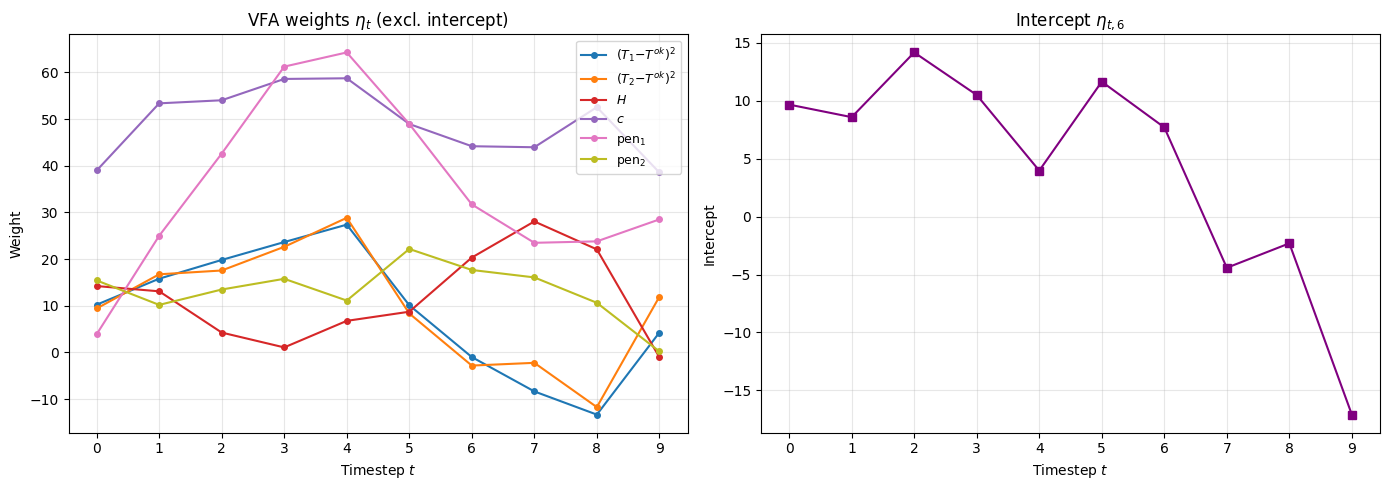

Saved: output/adp_weights_convergence.pdf


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ts  = np.arange(T)
lbs = ['$(T_1{-}T^{ok})^2$', '$(T_2{-}T^{ok})^2$', '$H$', '$c$', 'pen$_1$', 'pen$_2$']
clr = plt.cm.tab10(np.linspace(0, 0.8, 6))

for f in range(6):
    ax1.plot(ts, eta_all[:T, f], marker='o', markersize=4, label=lbs[f], color=clr[f])
ax1.set_title('VFA weights $\\eta_t$ (excl. intercept)')
ax1.set_xlabel('Timestep $t$'); ax1.set_ylabel('Weight')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3); ax1.set_xticks(ts)

ax2.plot(ts, eta_all[:T, 6], marker='s', color='purple')
ax2.set_title('Intercept $\\eta_{t,6}$')
ax2.set_xlabel('Timestep $t$'); ax2.set_ylabel('Intercept')
ax2.grid(True, alpha=0.3); ax2.set_xticks(ts)

plt.tight_layout()
plt.savefig('output/adp_weights_convergence.pdf', bbox_inches='tight')
plt.show()
print("Saved: output/adp_weights_convergence.pdf")

## Verification

`ADP_policy_14.py` loads `output/adp_weights.json` at import time.
Running the cell below confirms the file is readable and the shapes are correct.

In [12]:
with open('output/adp_weights.json') as f:
    check = json.load(f)

print("JSON keys:", list(check.keys()))
print(f"Timesteps in 'eta': {sorted(check['eta'].keys())}")
print(f"Feature vector length: {len(check['eta']['0'])}")
print()
print("ADP_policy_14.py will load this file and call select_action(state)")
print("which runs solve_adp_step(state, ETA[t], params) for t = state['current_time'].")

JSON keys: ['description', 'feature_names', 'eta']
Timesteps in 'eta': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Feature vector length: 11

ADP_policy_14.py will load this file and call select_action(state)
which runs solve_adp_step(state, ETA[t], params) for t = state['current_time'].
